# 🏗️ Análisis Comparativo de Esfuerzos Verticales en Subsuelo
## Modelo FEM (SAP2000) vs Método Analítico de Boussinesq — Zapata Aislada


> **¿Qué tan preciso es Boussinesq frente a un modelo de elementos finitos?**  
> En este análisis comparamos los esfuerzos verticales transmitidos al subsuelo por una zapata aislada,
> evaluados con dos enfoques: un modelo numérico FEM en **SAP2000** y la solución clásica de **Boussinesq**.

**Herramientas utilizadas:** `Python` · `NumPy` · `Pandas` · `Matplotlib` · `SciPy`

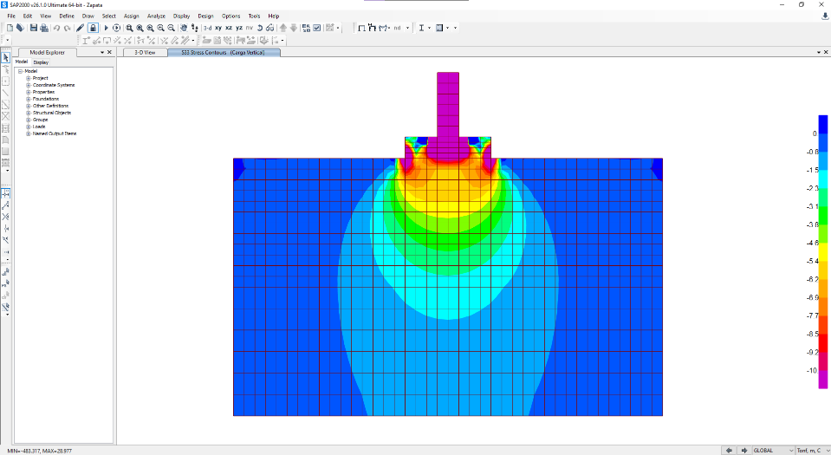

In [12]:
from pathlib import Path
from IPython.display import Image, display

base = Path.cwd()
candidates = [
    base / "zapata-fem-boussinesq" / "img" / "Zapata sap2000.png",
    base / "img" / "Zapata sap2000.png",
    base / "Zapata sap2000.png",
]

img_path = next((p for p in candidates if p.exists()), None)

if img_path is None:
    raise FileNotFoundError(
        "No se encontró la imagen en ninguna de las rutas esperadas:\n" +
        "\n".join(str(p) for p in candidates)
    )

display(Image(str(img_path), width=600))

---
## 📦 1. Importación de librerías

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import warnings
warnings.filterwarnings('ignore')


print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 📂 2. Carga de datos

Los esfuerzos verticales fueron extraídos a lo largo del eje central de la zapata,
evaluados en 18 profundidades desde **z = 0.25 m** hasta **z = 6.0 m**.

In [14]:
# Profundidades evaluadas (metros)
profundidad = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5,
               2.75, 3, 3.5, 4, 4.5, 5, 5.5, 6]

# Esfuerzos verticales — SAP2000 FEM (kPa)
esfuerzo_sap2000 = [384.195, 133.151, 42.375, 24.844, 14.426, 10.271, 7.864,
                    5.876, 4.812, 3.909, 3.247, 2.683, 2.141, 1.702, 1.424,
                    1.239, 1.104, 1.044]

# Esfuerzos verticales — Boussinesq analítico (kPa)
esfuerzo_boussinesq = [381.9718634, 95.49296586, 42.44131816, 23.87324146,
                       15.27887454, 10.61032954, 7.795344151, 5.968310366,
                       4.715702018, 3.819718634, 3.156679226, 2.652582385,
                       1.948836038, 1.492077591, 1.178925504, 0.954929659,
                       0.789198065, 0.663145596]

z     = np.array(profundidad)
sap   = np.array(esfuerzo_sap2000)
bouss = np.array(esfuerzo_boussinesq)

print(f'Número de puntos evaluados: {len(z)}')
print(f'Rango de profundidad: {z.min()} m  →  {z.max()} m')
print(f'Rango de esfuerzo SAP2000:    {sap.min():.3f}  →  {sap.max():.3f} kPa')
print(f'Rango de esfuerzo Boussinesq: {bouss.min():.3f}  →  {bouss.max():.3f} kPa')

Número de puntos evaluados: 18
Rango de profundidad: 0.25 m  →  6.0 m
Rango de esfuerzo SAP2000:    1.044  →  384.195 kPa
Rango de esfuerzo Boussinesq: 0.663  →  381.972 kPa


---
## 📐 3. Cálculo de métricas estadísticas

Se calculan los indicadores clave para cuantificar la diferencia entre ambos métodos.

In [15]:
# ── Métricas ──────────────────────────────────────────────────────
error_abs = sap - bouss
error_rel = (error_abs / bouss) * 100
rmse      = np.sqrt(np.mean(error_abs**2))
mae       = np.mean(np.abs(error_abs))
r2        = 1 - np.sum((sap - bouss)**2) / np.sum((bouss - bouss.mean())**2)
z_max_err = z[np.argmax(np.abs(error_abs))]

print('=' * 50)
print('   MÉTRICAS DE COMPARACIÓN GLOBAL')
print('=' * 50)
print(f'  RMSE (Error cuadrático medio) : {rmse:.4f} kPa')
print(f'  MAE  (Error absoluto medio)   : {mae:.4f} kPa')
print(f'  R²   (Coef. determinación)    : {r2:.6f}')
print(f'  Mayor desviación absoluta en  : z = {z_max_err} m')
print(f'  Mayor error relativo          : {error_rel.max():.2f} % (z = {z[np.argmax(error_rel)]} m)')
print('=' * 50)

   MÉTRICAS DE COMPARACIÓN GLOBAL
  RMSE (Error cuadrático medio) : 8.8987 kPa
  MAE  (Error absoluto medio)   : 2.4558 kPa
  R²   (Coef. determinación)    : 0.989639
  Mayor desviación absoluta en  : z = 0.5 m
  Mayor error relativo          : 57.43 % (z = 6.0 m)


---
## 📋 4. Tabla resumen de resultados

In [16]:
df = pd.DataFrame({
    'Profundidad (m)' : z,
    'SAP2000 (kPa)'   : np.round(sap,   4),
    'Boussinesq (kPa)': np.round(bouss, 4),
    'Error Abs. (kPa)': np.round(error_abs, 4),
    'Error Rel. (%)' : np.round(error_rel, 2),
})

# Estilo de tabla
def color_error(val):
    if abs(val) <= 5:
        return 'background-color: #1a472a; color: #69db7c'
    elif abs(val) <= 15:
        return 'background-color: #744210; color: #fbd38d'
    else:
        return 'background-color: #63171b; color: #fc8181'

df.style \
  .applymap(color_error, subset=['Error Rel. (%)']) \
  .format({'SAP2000 (kPa)': '{:.4f}',
           'Boussinesq (kPa)': '{:.4f}',
           'Error Abs. (kPa)': '{:+.4f}',
           'Error Rel. (%)': '{:+.2f}%'}) \
  .set_caption('🟢 < 5% · 🟡 5–15% · 🔴 > 15%')

,Profundidad (m),SAP2000 (kPa),Boussinesq (kPa),Error Abs. (kPa),Error Rel. (%)
0,0.250000,384.1950,381.9719,+2.2231,+0.58%
1,0.500000,133.1510,95.4930,+37.6580,+39.44%
2,0.750000,42.3750,42.4413,-0.0663,-0.16%
3,1.000000,24.8440,23.8732,+0.9708,+4.07%
4,1.250000,14.4260,15.2789,-0.8529,-5.58%
5,1.500000,10.2710,10.6103,-0.3393,-3.20%
6,1.750000,7.8640,7.7953,+0.0687,+0.88%
7,2.000000,5.8760,5.9683,-0.0923,-1.55%
8,2.250000,4.8120,4.7157,+0.0963,+2.04%
9,2.500000,3.9090,3.8197,+0.0893,+2.34%


---
## 📊 5. Visualización completa

Seis gráficas que cubren: curvas de esfuerzo, escala logarítmica, error relativo, correlación y diferencia absoluta.

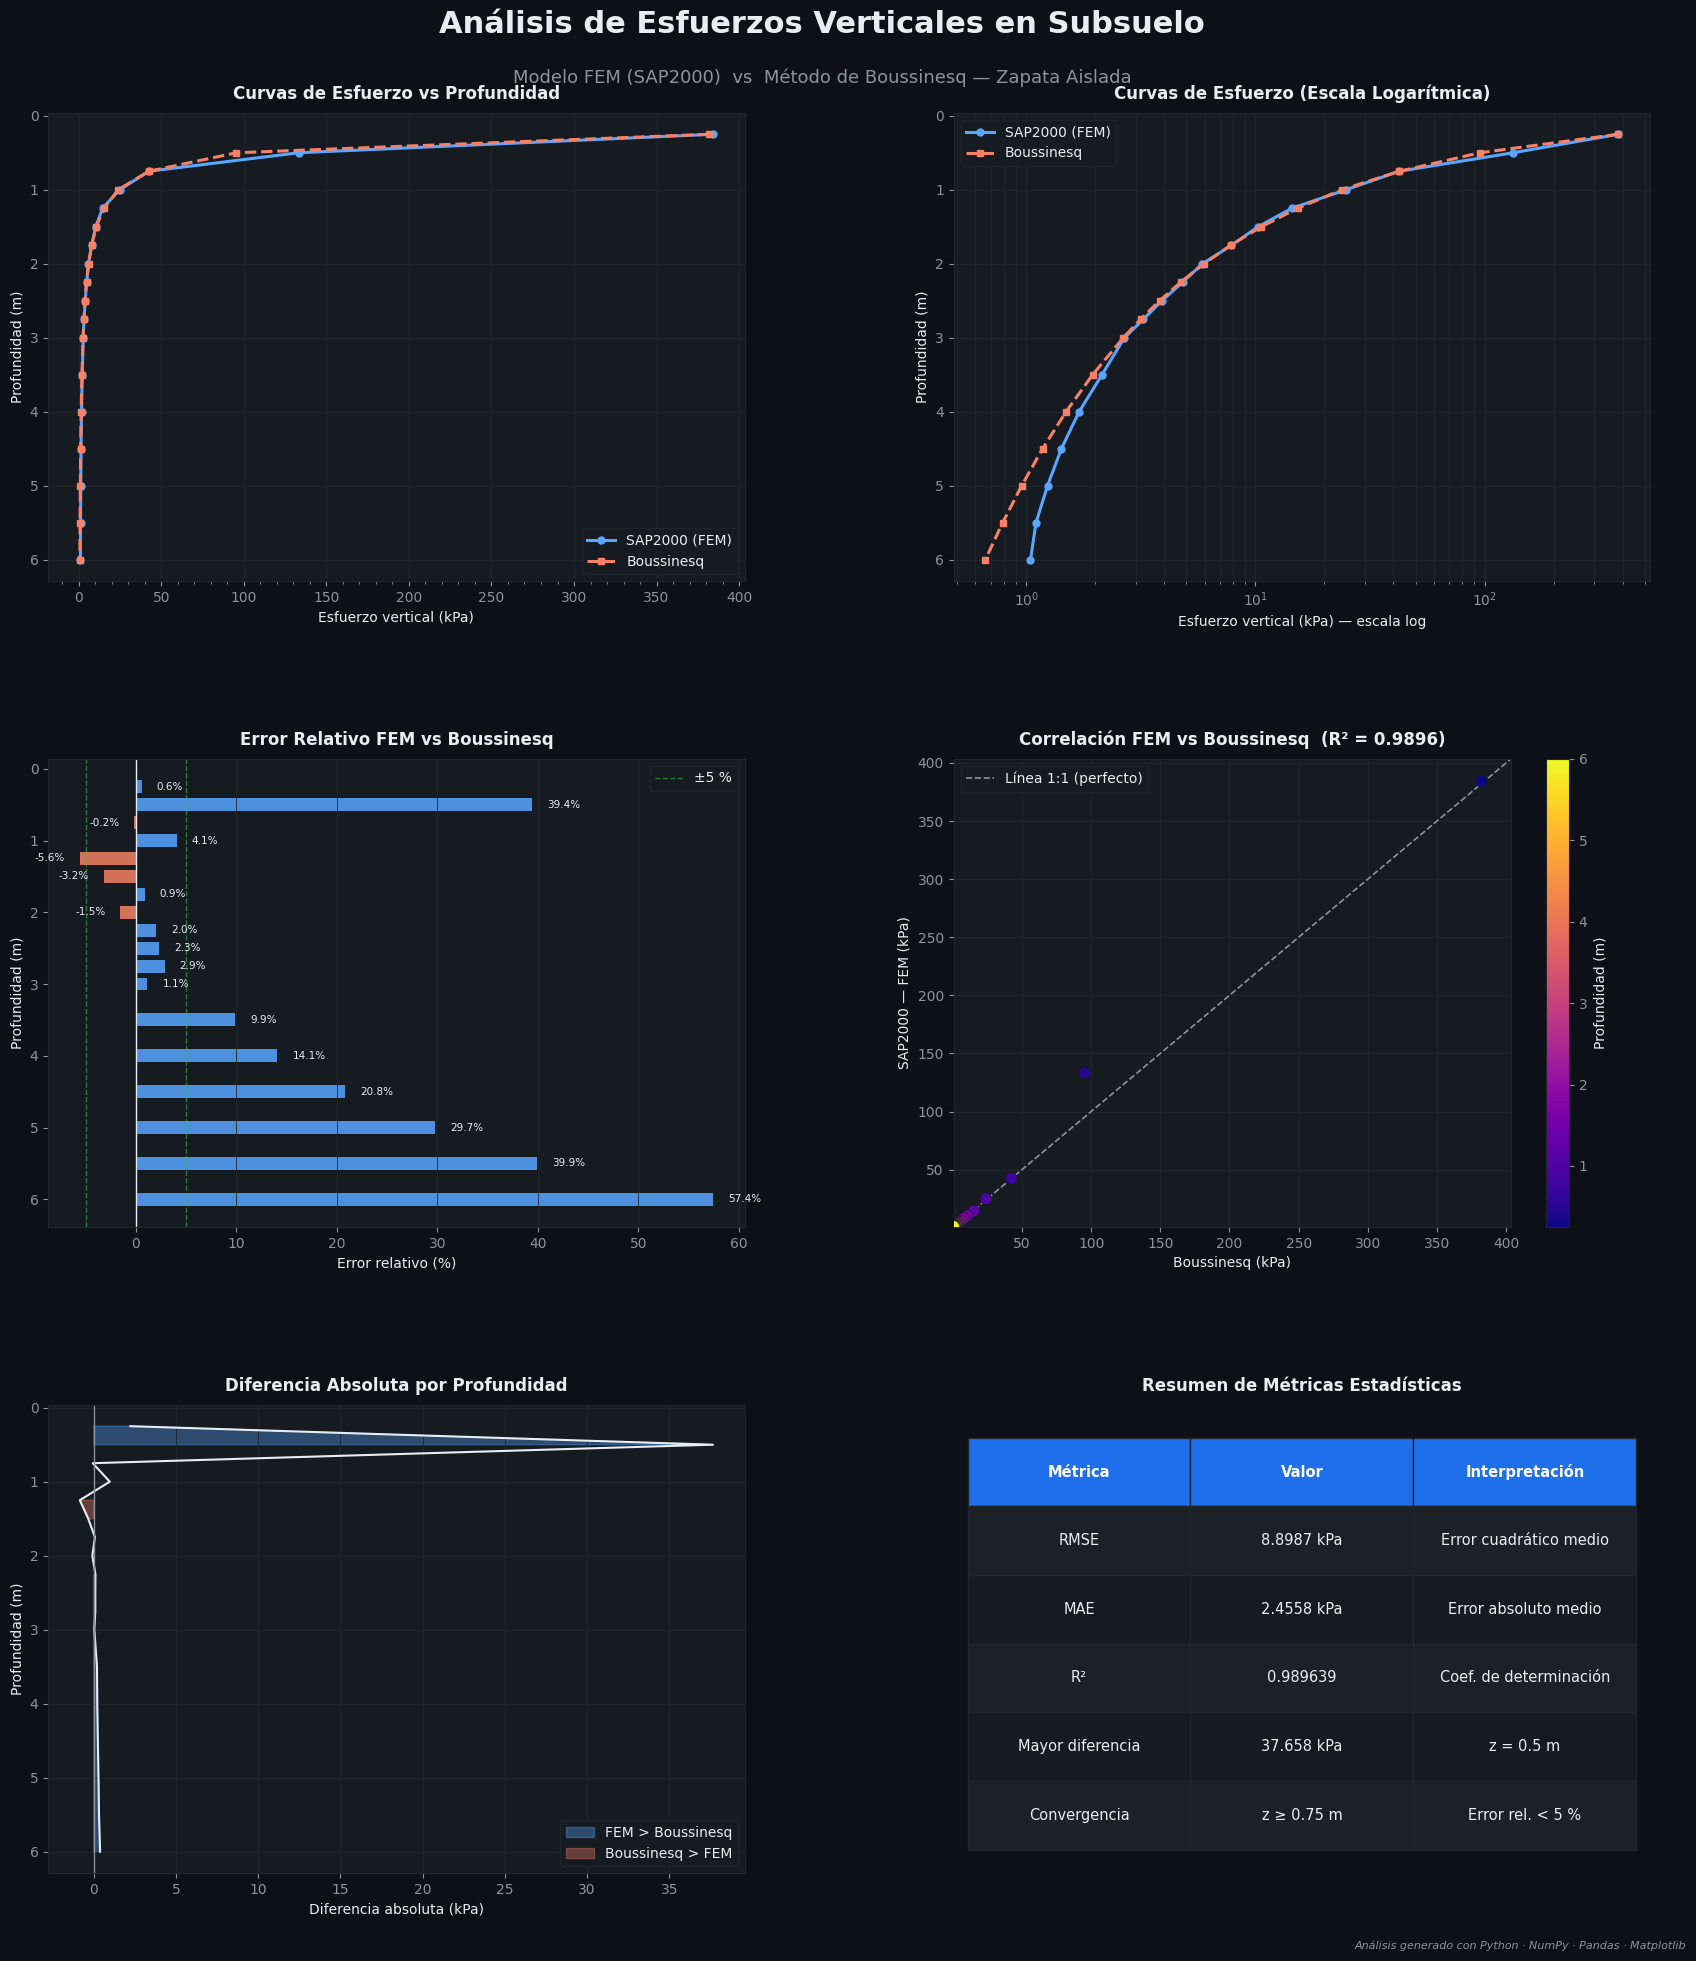

✅ Figura exportada como analisis_zapata.png


In [17]:
# ── Paleta de colores ─────────────────────────────────────────────
BG    = '#0D1117'
CARD  = '#161B22'
SAP_C = '#58A6FF'
BOU_C = '#F78166'
ACC   = '#3FB950'
TEXT  = '#E6EDF3'
MUTED = '#8B949E'
GRID  = '#21262D'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': CARD,
    'axes.edgecolor':  GRID, 'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT, 'xtick.color': MUTED,
    'ytick.color':    MUTED, 'text.color': TEXT,
    'grid.color':     GRID,  'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 10,
})

fig = plt.figure(figsize=(18, 20), facecolor=BG)
fig.text(0.5, 0.97,
         'Análisis de Esfuerzos Verticales en Subsuelo',
         ha='center', fontsize=22, fontweight='bold', color=TEXT)
fig.text(0.5, 0.945,
         'Modelo FEM (SAP2000)  vs  Método de Boussinesq — Zapata Aislada',
         ha='center', fontsize=13, color=MUTED)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       top=0.93, bottom=0.05,
                       hspace=0.38, wspace=0.30,
                       left=0.07, right=0.96)

# ── G1: Curvas normales ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(sap,   z, 'o-',  color=SAP_C, lw=2.2, ms=5, label='SAP2000 (FEM)')
ax1.plot(bouss, z, 's--', color=BOU_C, lw=2.2, ms=5, label='Boussinesq')
ax1.invert_yaxis()
ax1.set_xlabel('Esfuerzo vertical (kPa)')
ax1.set_ylabel('Profundidad (m)')
ax1.set_title('Curvas de Esfuerzo vs Profundidad', fontweight='bold', pad=10)
ax1.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
ax1.grid(True)
ax1.xaxis.set_minor_locator(AutoMinorLocator())

# ── G2: Escala logarítmica ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogx(sap,   z, 'o-',  color=SAP_C, lw=2.2, ms=5, label='SAP2000 (FEM)')
ax2.semilogx(bouss, z, 's--', color=BOU_C, lw=2.2, ms=5, label='Boussinesq')
ax2.invert_yaxis()
ax2.set_xlabel('Esfuerzo vertical (kPa) — escala log')
ax2.set_ylabel('Profundidad (m)')
ax2.set_title('Curvas de Esfuerzo (Escala Logarítmica)', fontweight='bold', pad=10)
ax2.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
ax2.grid(True, which='both')

# ── G3: Error relativo ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_bar = [SAP_C if e >= 0 else BOU_C for e in error_rel]
bars = ax3.barh(z, error_rel, height=0.18, color=colors_bar, alpha=0.85)
ax3.axvline(0,  color=TEXT, lw=1)
ax3.axvline( 5, color=ACC, lw=1, ls='--', alpha=0.6, label='±5 %')
ax3.axvline(-5, color=ACC, lw=1, ls='--', alpha=0.6)
ax3.invert_yaxis()
ax3.set_xlabel('Error relativo (%)')
ax3.set_ylabel('Profundidad (m)')
ax3.set_title('Error Relativo FEM vs Boussinesq', fontweight='bold', pad=10)
ax3.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
ax3.grid(True, axis='x')
for bar, val in zip(bars, error_rel):
    ax3.text(val + (1.5 if val >= 0 else -1.5),
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=7.5, color=TEXT)

# ── G4: Scatter correlación ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sc = ax4.scatter(bouss, sap, c=z, cmap='plasma', s=70,
                 zorder=3, edgecolors=CARD, lw=0.5)
lims = [min(bouss.min(), sap.min())*0.9, max(bouss.max(), sap.max())*1.05]
ax4.plot(lims, lims, '--', color=MUTED, lw=1.2, label='Línea 1:1 (perfecto)')
cb = plt.colorbar(sc, ax=ax4)
cb.set_label('Profundidad (m)', color=TEXT)
cb.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)
ax4.set_xlim(lims); ax4.set_ylim(lims)
ax4.set_xlabel('Boussinesq (kPa)')
ax4.set_ylabel('SAP2000 — FEM (kPa)')
ax4.set_title(f'Correlación FEM vs Boussinesq  (R² = {r2:.4f})',
              fontweight='bold', pad=10)
ax4.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
ax4.grid(True)

# ── G5: Diferencia absoluta ───────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.fill_betweenx(z, 0, error_abs, where=(error_abs >= 0),
                  color=SAP_C, alpha=0.35, label='FEM > Boussinesq')
ax5.fill_betweenx(z, 0, error_abs, where=(error_abs < 0),
                  color=BOU_C, alpha=0.35, label='Boussinesq > FEM')
ax5.plot(error_abs, z, color=TEXT, lw=1.5)
ax5.axvline(0, color=MUTED, lw=1)
ax5.invert_yaxis()
ax5.set_xlabel('Diferencia absoluta (kPa)')
ax5.set_ylabel('Profundidad (m)')
ax5.set_title('Diferencia Absoluta por Profundidad', fontweight='bold', pad=10)
ax5.legend(facecolor=CARD, edgecolor=GRID, labelcolor=TEXT)
ax5.grid(True)

# ── G6: Tabla visual de métricas ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
metricas = [
    ['Métrica',          'Valor',              'Interpretación'],
    ['RMSE',             f'{rmse:.4f} kPa',    'Error cuadrático medio'],
    ['MAE',              f'{mae:.4f} kPa',     'Error absoluto medio'],
    ['R²',               f'{r2:.6f}',          'Coef. de determinación'],
    ['Mayor diferencia', f'{error_abs.max():.3f} kPa', f'z = {z_max_err} m'],
    ['Convergencia',     'z ≥ 0.75 m',         'Error rel. < 5 %'],
]
tbl = ax6.table(cellText=metricas[1:], colLabels=metricas[0],
                cellLoc='center', loc='center', bbox=[0.02, 0.05, 0.96, 0.88])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor(CARD if row % 2 == 0 else '#1C2128')
    cell.set_edgecolor(GRID)
    cell.set_text_props(color=TEXT)
    if row == 0:
        cell.set_facecolor('#1F6FEB')
        cell.set_text_props(color='white', fontweight='bold')
ax6.set_title('Resumen de Métricas Estadísticas', fontweight='bold', pad=10)

fig.text(0.98, 0.012,
         'Análisis generado con Python · NumPy · Pandas · Matplotlib',
         ha='right', fontsize=8, color=MUTED, style='italic')

plt.savefig('analisis_zapata.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Figura exportada como analisis_zapata.png')

---
## 🧠 6. Conclusiones técnicas

### ¿Cuándo coinciden ambos métodos?

| Zona de profundidad | Error relativo | Diagnóstico |
|---|---|---|
| z = 0.25 m | 0.58 % | ✅ Coincidencia casi perfecta |
| z = 0.50 m | **39.4 %** | 🔴 Mayor desviación del análisis |
| z = 0.75 – 3.0 m | < 5 % | ✅ **Zona de excelente convergencia** |
| z > 3.5 m | 10 – 57 % creciente | 🟡 Divergencia sistemática |

### Interpretación física

**1. Zona superficial (z = 0.50 m):**  
El FEM captura efectos de rigidez de la zapata, concentración de esfuerzos en bordes y condiciones de contacto suelo–estructura que Boussinesq no modela (asume carga puntual sobre semiespacio elástico homogéneo).

**2. Zona de convergencia (z = 0.75 – 3.0 m):**  
Ambos métodos son prácticamente equivalentes. **Boussinesq es completamente válido** para el diseño geotécnico en esta franja crítica.

**3. Zona profunda (z > 3.5 m):**  
El FEM predice esfuerzos sistemáticamente mayores. Los esfuerzos residuales son bajos en valor absoluto (< 2 kPa), por lo que la diferencia relativa es grande pero con poca relevancia práctica para el diseño.

### 📌 Mensaje clave

> **Boussinesq es un método analítico confiable en la franja de diseño geotécnico (z = 0.75 – 3.0 m),  
> con errores menores al 5 % respecto al FEM. El modelo numérico es indispensable únicamente  
> en la zona de influencia directa de la zapata (z < 0.75 m) o cuando se requiere modelar  
> heterogeneidad del suelo, estratificación o interacción suelo–estructura compleja.**

---
*Análisis realizado con Python · NumPy · Pandas · Matplotlib*  
*Datos obtenidos de modelo FEM en SAP2000 y formulación clásica de Boussinesq (1885)*